In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


In [2]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Torch version: 2.8.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
## new transform
import torchvision.transforms as T

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    T.Resize(320),
    T.RandomResizedCrop(288, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), inplace=True),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize(320),
    T.CenterCrop(288),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
train_data = datasets.ImageFolder("../data/split/train", transform=train_transform)
test_data  = datasets.ImageFolder("../data/split/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_data.classes)
print("Total Classes:", num_classes)


Total Classes: 79


In [ ]:
model = models.resnet50(pretrained=True)

# Freeze early layers
# for param in model.parameters():
#     param.requires_grad = True

# Replace final layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)



for p in model.parameters():
    p.requires_grad = True

model = model.to(device)






c:\Users\Harsh\.conda\envs\new_yoga\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Harsh\.conda\envs\new_yoga\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
## new 
from collections import Counter
import torch

# for ImageFolder-style dataset
counts = Counter(train_data.targets)
num_classes = len(train_data.classes)
class_weights = torch.tensor([1.0 / counts[i] for i in range(num_classes)], dtype=torch.float)
class_weights = class_weights.to("cuda")
criterion = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)  # label smoothing helps

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6
)
# after computing val_acc each epoch:




In [7]:
import os

checkpoint_dir = "torch_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, path)
    print(f"✅ Checkpoint saved at epoch {epoch+1}")

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"🔄 Resumed from checkpoint at epoch {start_epoch}")
    return model, optimizer, start_epoch


In [8]:
from tqdm import tqdm
import json
import torch
import os

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=20, checkpoint_dir="torch_checkpoints"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, "last_checkpoint.pth")
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    history_path = os.path.join(checkpoint_dir, "history.json")

    start_epoch = 0
    best_val_acc = 0.0

    # ---------------- Resume ----------------
    if os.path.exists(checkpoint_path):
        print("Resuming training from checkpoint...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        start_epoch = checkpoint["epoch"] + 1
        best_val_acc = checkpoint.get("best_val_acc", 0.0)

    # ---------------- History ----------------
    if os.path.exists(history_path):
        with open(history_path, "r") as f:
            history = json.load(f)
    else:
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    # ---------------- AMP Scaler ----------------
    scaler = torch.amp.GradScaler(device="cuda")

    # ---------------- Training Loop ----------------
    for epoch in range(start_epoch, num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # -------- Mixed Precision Forward --------
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            # -------- Scaled Backward --------
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= len(test_loader)
        val_acc = 100.0 * val_correct / val_total

        scheduler.step(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f} Acc: {val_acc:.2f}%")

        # ---------------- Save history ----------------
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        with open(history_path, "w") as f:
            json.dump(history, f)

        # ---------------- Save checkpoints ----------------
        checkpoint = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
        }
        torch.save(checkpoint, checkpoint_path)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Best model updated at epoch {epoch+1} (Val Acc: {val_acc:.2f}%)")

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


In [9]:
train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=200,               # increase if needed
    checkpoint_dir="torch_checkpoints" # directory to save
)

Resuming training from checkpoint...

Epoch 71/200


100%|██████████| 244/244 [01:48<00:00,  2.26it/s]
C:\Users\Harsh\AppData\Local\Temp\ipykernel_25428\620187414.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [71/200] Loss: 0.9753 Acc: 84.32%
Train Loss: 0.9753, Train Acc: 98.65% | Val Loss: 1.3592, Val Acc: 84.32%

Epoch 72/200


100%|██████████| 244/244 [01:39<00:00,  2.46it/s]


Epoch [72/200] Loss: 0.9697 Acc: 84.67%
Train Loss: 0.9697, Train Acc: 98.81% | Val Loss: 1.3538, Val Acc: 84.67%

Epoch 73/200


...

Epoch [146/200] Loss: 0.9506 Acc: 85.07%
Train Loss: 0.9506, Train Acc: 99.06% | Val Loss: 1.3417, Val Acc: 85.07%

Epoch 147/200


100%|██████████| 244/244 [01:40<00:00,  2.42it/s]


Epoch [147/200] Loss: 0.9537 Acc: 84.87%
Train Loss: 0.9537, Train Acc: 99.06% | Val Loss: 1.3427, Val Acc: 84.87%

Epoch 148/200


 50%|█████     | 123/244 [01:00<00:59,  2.02it/s]


KeyboardInterrupt: 

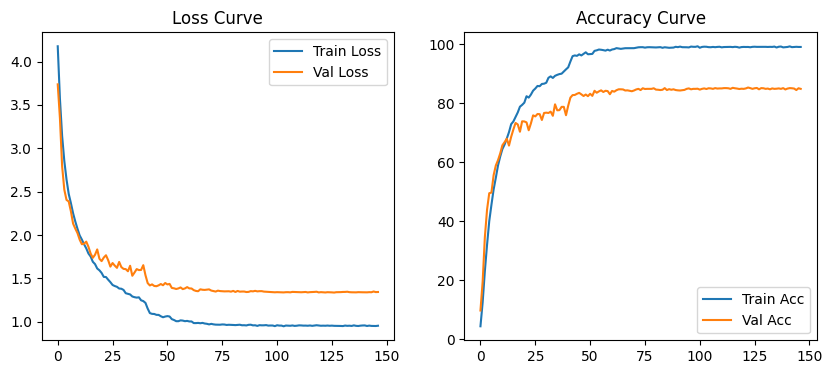

In [2]:
import matplotlib.pyplot as plt
import json

with open("torch_checkpoints/history.json") as f:
    history = json.load(f)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.legend(); plt.title("Accuracy Curve")

plt.show()
